# Notebook 1. Weight decay 3e-5 against no weight decay

**The question.** Can we tell early on when a run will grok? We read three numbers about the kernel near the start of training, `A_t`, `S_t` and `R_t`. Then we check whether a simple model can use them to predict the grokking step.

**The two experiments.** We look at 90 runs with weight decay 3e-5, where nearly every run groks. We compare them with 90 runs with no weight decay, which is the published baseline. Notebook 2 does the same with every weight decay level together.

**The short answer.**

- With weight decay 3e-5, adding the kernel to the settings helps a little on held-out cells, in every model. For the AFT the concordance goes from 0.890 to 0.902.
- Without weight decay, the settings already order the runs almost perfectly, and the kernel adds nothing to the time models. It does help the yes/no question of whether a run groks at all.
- Among the seeds of one cell, the kernel at the landmark says nothing about which seed groks first.

### Words you need

| Word | What it means |
| --- | --- |
| step | One update of the weights. Each run gets 200,000 steps, which is the **budget**. |
| grokked | The test accuracy reached 0.95. The **grokking step** `T` is the first step where that happens, counted from step 0 (report §3.5). |
| censored | The run never reached 0.95 within the budget. We keep it, and we know only that `T` is over 200,000. |
| memorised | The training accuracy reached 0.99. |
| cell | One mix of `alpha`, width `N` and weight decay `ηλ`. Each cell has 5 seeds. |
| `alpha` | The laziness knob. A bigger `alpha` lets the network fit the data while its weights move less. |
| kernel | A table that says how much a training step on one input moves the output on another. We use the report's kernel of the summed outputs on the 53 test pairs (Eq. 5). |
| `S_t` | How much bigger the kernel is than at step 0. 1 means the same size. |
| `R_t` | How much the kernel has turned since step 0. 0 means the same shape. |
| `A_t` | How well the kernel lines up with the labels. Higher means inputs with the same answer look more alike. |
| landmark | Step 2,430. We read the kernel there, before any run groks. |

Blue is weight decay 3e-5 and orange is no weight decay. Violet, teal and gold mark `A_t`, `S_t` and `R_t`.

**The split.** Each seed has its own train/test split, as in report §3.1. Seed `s` uses data seed 42 + `s`.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2
from lifelines import CoxPHFitter, CoxTimeVaryingFitter, KaplanMeierFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

plt.style.use('fitting.mplstyle')
WD_COLOUR, NO_WD_COLOUR, GREY, INK, SURFACE = '#2a78d6', '#eb6834', '#8a8984', '#0b0b0b', '#fcfcfb'
KERNEL_COLOURS = {'A_t': '#7b5cd6', 'S_t': '#1a9e8f', 'R_t': '#c99a06'}
kernel = ['A_t', 'S_t', 'R_t']
LANDMARK = 2_430

## Load the data

We need three files. `runs.parquet` holds the settings of each run. `checkpoints.parquet` holds the accuracies at every checkpoint. `report_kernel.parquet` holds `A_t`, `S_t`, `R_t` and `D_t` at 48 steps of each run, made by `report_kernel.py`.

In [2]:
runs = pd.read_parquet('data/runs.parquet', columns=['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step', 'test_acc_final'])
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'train_acc', 'test_acc'])
kern = pd.read_parquet('data/report_kernel.parquet')

# The first step at which each accuracy reaches each level. NaN means it never did.
events = runs.set_index('run_id')
events['t_mem99'] = acc[acc['train_acc'] >= 0.99].groupby('run_id')['step'].min()
for level in [80, 90, 95]:
    events[f't_gen{level}'] = acc[acc['test_acc'] >= level / 100].groupby('run_id')['step'].min()
events = events.reset_index()

events['grokked'] = events['t_gen95'].notna().astype(int)     # 1 = grokked, 0 = censored
events['T'] = events['t_gen95'].fillna(events['last_step'])    # the grokking step, or 200,000 if censored
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))

# Add the kernel numbers at the landmark.
data = events.merge(kern[kern['step'] == LANDMARK].drop(columns='step'), on='run_id')

WD_LABEL, NO_WD_LABEL = 'weight decay 3e-5', 'no weight decay'
wd = data[np.isclose(data['eta_kappa'], 3e-5)].copy()
no_wd = data[data['eta_kappa'] == 0].copy()
sets = {WD_LABEL: wd, NO_WD_LABEL: no_wd}
colours = {WD_LABEL: WD_COLOUR, NO_WD_LABEL: NO_WD_COLOUR}

pd.DataFrame({label: {'runs': len(df), 'cells': df['cell'].nunique(), 'grokked': df['grokked'].sum()}
              for label, df in sets.items()})

,weight decay 3e-5,no weight decay
runs,90,90
cells,18,18
grokked,87,23


In [3]:
wd[['run_id', 'cell', 'T', 'grokked'] + kernel].head()

,run_id,cell,T,grokked,A_t,S_t,R_t
15,ntk_N50_a0.5_wd3e-05_s0,0.5_50_3e-05,4981.0,1,0.337286,2.655067,0.083007
16,ntk_N50_a0.5_wd3e-05_s1,0.5_50_3e-05,9000.0,1,0.329439,2.258183,0.077810
17,ntk_N50_a0.5_wd3e-05_s2,0.5_50_3e-05,5520.0,1,0.336578,2.589124,0.077729
18,ntk_N50_a0.5_wd3e-05_s3,0.5_50_3e-05,6776.0,1,0.321765,2.818793,0.092287
19,ntk_N50_a0.5_wd3e-05_s4,0.5_50_3e-05,7508.0,1,0.352881,2.913403,0.124933


Each row is one run. `T` is the grokking step and `grokked` says whether we saw it. The last three columns are the kernel numbers at the landmark.

## Part 1. Where do the runs grok?

For each `alpha` and width, how many of the 5 seeds grok?

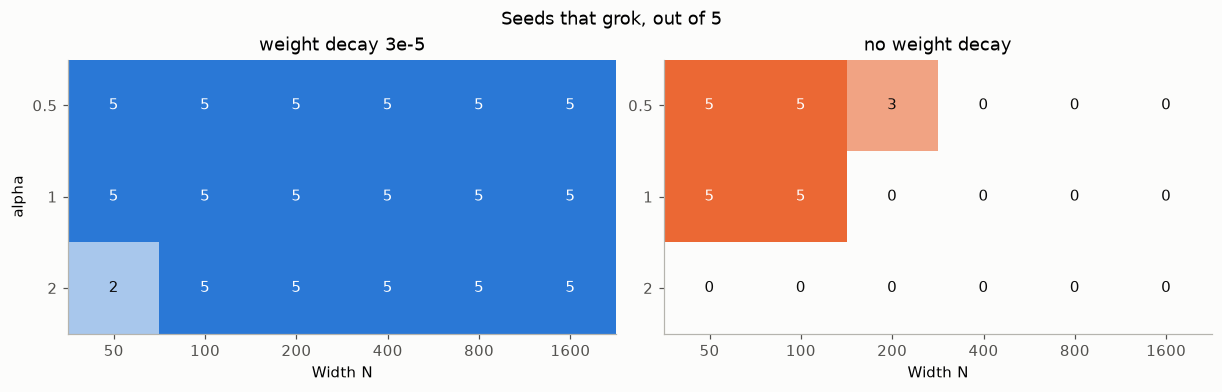

In [4]:
widths = [50, 100, 200, 400, 800, 1600]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout='constrained')
for ax, (label, df) in zip(axes, sets.items()):
    counts = df.pivot_table(index='alpha', columns='width', values='grokked', aggfunc='sum')
    ax.imshow(counts, cmap=LinearSegmentedColormap.from_list(label, [SURFACE, colours[label]]), vmin=0, vmax=5)
    for i in range(counts.shape[0]):
        for j in range(counts.shape[1]):
            n = counts.iloc[i, j]
            ax.text(j, i, n, ha='center', va='center', color='white' if n >= 4 else INK)
    ax.set_xticks(range(len(widths)), widths)
    ax.set_yticks(range(3), ['0.5', '1', '2'])
    ax.set_xlabel('Width N')
    ax.set_title(label)
    ax.grid(False)
axes[0].set_ylabel('alpha')
fig.suptitle('Seeds that grok, out of 5', y=1.06)
plt.show()

**Takeaway.**

- With weight decay 3e-5, almost every run groks. Only `alpha` 2 at width 50 struggles, with 2 seeds of 5.
- Without weight decay, only small networks at small `alpha` grok. Nothing at `alpha` 2 groks.

## Part 2. How long does grokking take?

We want one typical grokking step per cell. Some seeds never grok, so a plain median would leave them out. The **Kaplan-Meier** median keeps them: a censored seed counts as "not grokked yet" for the whole budget (report Eq. 9). If fewer than half the seeds grok, the cell has no median.

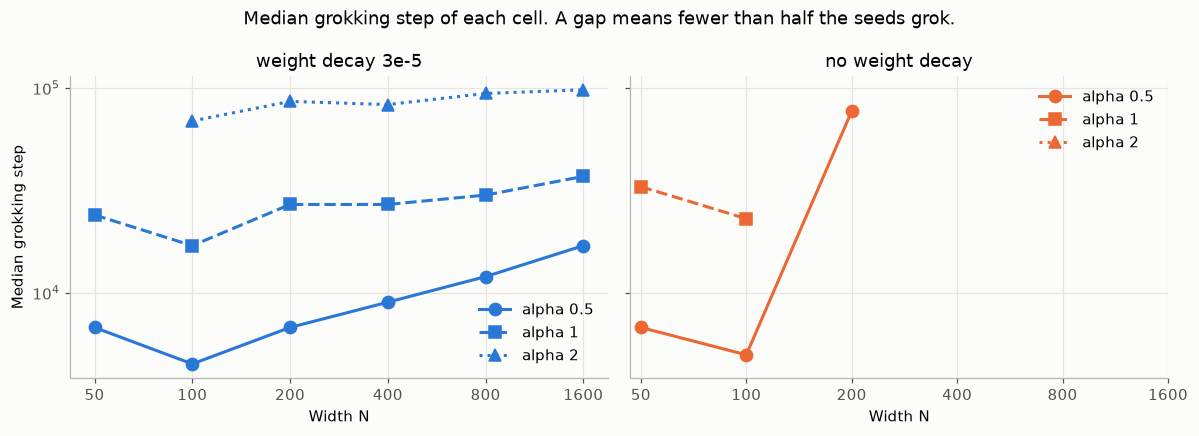

In [5]:
rows = []
for label, df in sets.items():
    for cell, g in df.groupby('cell'):
        km = KaplanMeierFitter().fit(g['T'], g['grokked'])
        rows.append({'group': label, 'alpha': g['alpha'].iloc[0], 'width': g['width'].iloc[0],
                     'median T': km.median_survival_time_})
cell_medians = pd.DataFrame(rows).replace(np.inf, np.nan).sort_values(['group', 'alpha', 'width'])

styles = {0.5: ('o', '-'), 1.0: ('s', '--'), 2.0: ('^', ':')}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, label in zip(axes, sets):
    for a, (marker, line) in styles.items():
        m = cell_medians[(cell_medians['group'] == label) & (cell_medians['alpha'] == a)]
        ax.plot(m['width'], m['median T'], marker=marker, linestyle=line, markersize=8, color=colours[label],
                label=f'alpha {a:g}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(widths, widths)
    ax.minorticks_off()
    ax.set_xlabel('Width N')
    ax.set_title(label)
    ax.legend()
axes[0].set_ylabel('Median grokking step')
fig.suptitle('Median grokking step of each cell. A gap means fewer than half the seeds grok.')
plt.tight_layout()
plt.show()

The two groups share a few cells where both have a median. Here they are side by side.

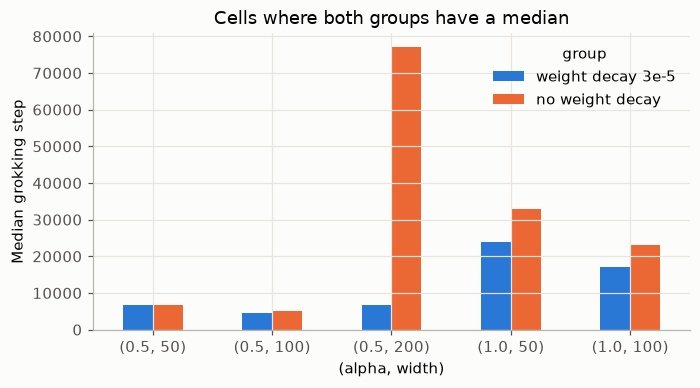

group        no weight decay  weight decay 3e-5  no wd / wd
alpha width                                                
0.5   50              6776.0             6776.0        1.00
      100             4981.0             4496.0        1.11
      200            77000.0             6776.0       11.36
1.0   50             33000.0            24000.0        1.38
      100            23000.0            17000.0        1.35

In [6]:
shared = cell_medians.pivot(index=['alpha', 'width'], columns='group', values='median T').dropna()
shared['no wd / wd'] = shared[NO_WD_LABEL] / shared[WD_LABEL]

ax = shared[[WD_LABEL, NO_WD_LABEL]].plot.bar(color=[WD_COLOUR, NO_WD_COLOUR], rot=0, figsize=(7, 3.5))
ax.set_xlabel('(alpha, width)')
ax.set_ylabel('Median grokking step')
ax.set_title('Cells where both groups have a median')
plt.show()
shared.round(2)

**Takeaway.**

- With weight decay 3e-5, a bigger `alpha` means a much later grokking step. Past width 100, a wider network is a bit slower too.
- Without weight decay only 5 cells have a median.
- Where both groups have a median, no weight decay is never faster. It takes 1.0 to 1.4 times as long, and 11 times as long at `alpha` 0.5 and width 200.

## Part 3. What the kernel does during training

We follow the report's pilot cell (`alpha` 1, width 100, no weight decay, report §4.1) and the same cell with weight decay 3e-5. The line is the median of the 5 seeds and the band spans them, as in report Fig. 1. The dotted line is the landmark.

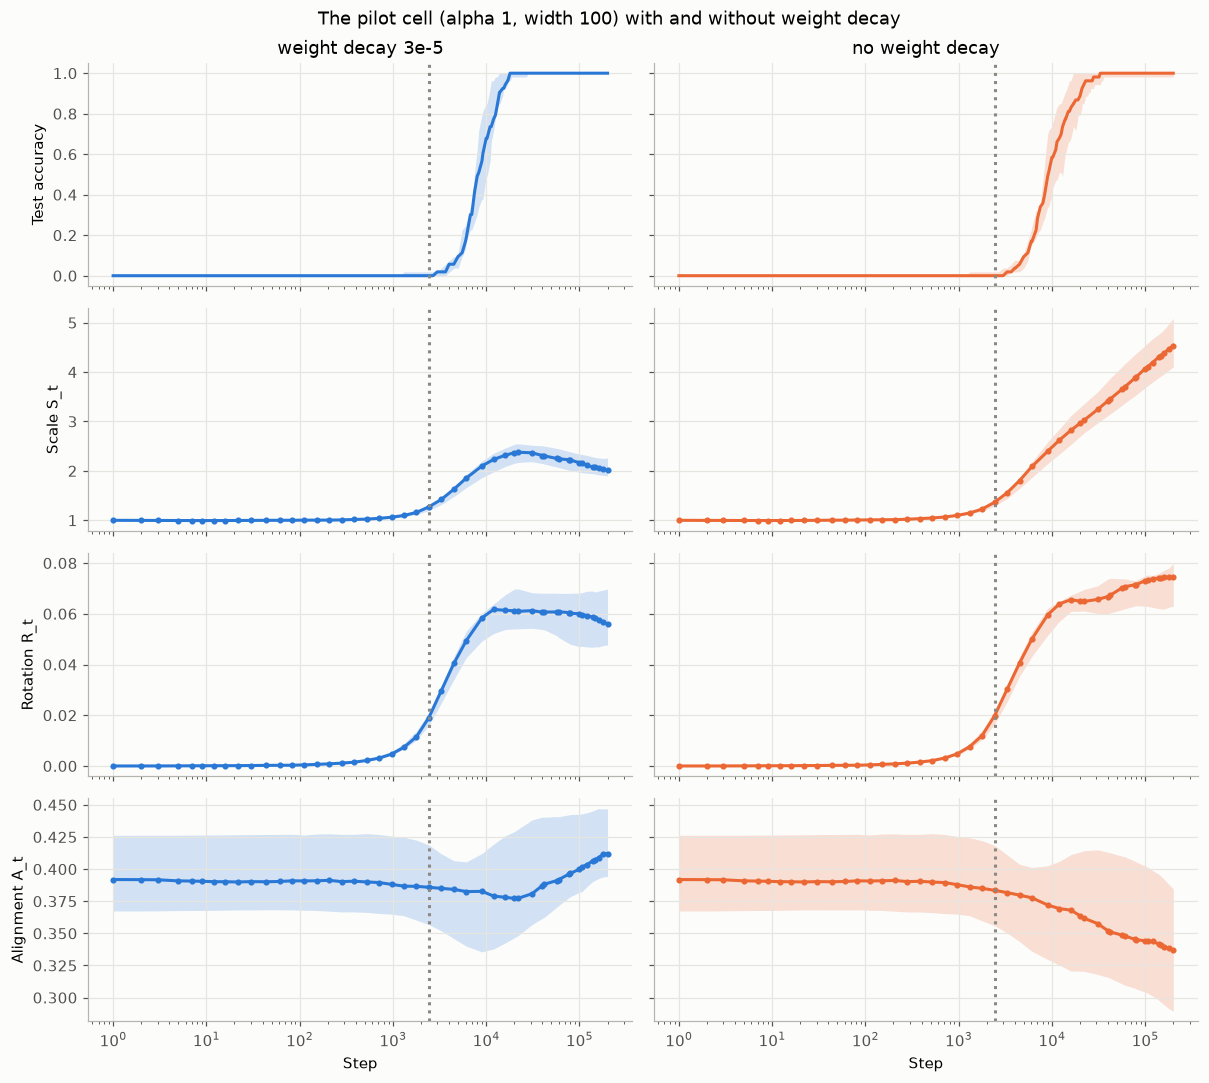

In [7]:
pilot = {WD_LABEL: 'ntk_N100_a1_wd3e-05_s', NO_WD_LABEL: 'ntk_N100_a1_wd0_s'}
panels = [('test_acc', 'Test accuracy', acc), ('S_t', 'Scale S_t', kern), ('R_t', 'Rotation R_t', kern),
          ('A_t', 'Alignment A_t', kern)]

fig, axes = plt.subplots(4, 2, figsize=(11, 10), sharex=True, sharey='row')
for j, (label, prefix) in enumerate(pilot.items()):
    for i, (col, name, table) in enumerate(panels):
        sub = table[table['run_id'].str.startswith(prefix) & (table['step'] > 0)]
        band = sub.groupby('step')[col].agg(['min', 'median', 'max'])
        ax = axes[i, j]
        ax.fill_between(band.index, band['min'], band['max'], color=colours[label], alpha=0.2, linewidth=0)
        ax.plot(band.index, band['median'], color=colours[label], marker='.' if table is kern else None)
        ax.axvline(LANDMARK, color=GREY, linestyle=':')
        axes[i, 0].set_ylabel(name)
    axes[0, j].set_title(label)
    axes[-1, j].set_xscale('log')
    axes[-1, j].set_xlabel('Step')
fig.suptitle('The pilot cell (alpha 1, width 100) with and without weight decay')
plt.tight_layout()
plt.show()

As a check, here are the numbers of the pilot cell next to report Table 2. The values are the medians over the 5 seeds.

In [8]:
pilot_steps = kern[kern['run_id'].str.startswith(pilot[NO_WD_LABEL]) & kern['step'].isin([0, 100_000])]
table2 = pilot_steps.groupby('step')[['A_t', 'S_t', 'R_t', 'D_t']].median().T
table2.columns = ['ours, step 0', 'ours, step 100,000']
table2['report Table 2, step 0'] = [0.40, 1, 0, 0]
table2['report Table 2, step 100,000'] = [0.34, 4, 0.068, 3.1]
table2.round(3)

,"ours, step 0","ours, step 100,000","report Table 2, step 0","report Table 2, step 100,000"
A_t,0.392,0.344,0.4,0.340
S_t,1.000,4.068,1.0,4.000
R_t,0.000,0.073,0.0,0.068
D_t,0.000,3.166,0.0,3.100


**Takeaway.**

- Our numbers match report Table 2 closely, so the rebuilt kernel is the report's kernel.
- All three numbers start to move shortly before the test accuracy climbs. At the landmark they have only just started.
- Before grokking the two runs look alike, and they split afterwards. Without weight decay `S_t` keeps growing and `A_t` keeps falling. With weight decay `S_t` peaks near 2.4 and drifts back to 2.0, and `A_t` climbs back up.

## Part 4. No peeking

A model that predicts grokking must use only what is known before the run groks. So we read the kernel at the landmark, step 2,430. The check below makes sure no run, in any group, has grokked by then at any of the three levels.

In [9]:
earliest = events[['t_gen80', 't_gen90', 't_gen95']].min()
assert (earliest > LANDMARK).all(), 'a run grokked before the landmark'
pd.Series({'earliest step at test accuracy 0.80': earliest['t_gen80'],
           'earliest step at test accuracy 0.95': earliest['t_gen95'],
           'highest test accuracy at the landmark': acc.loc[acc['step'] == LANDMARK, 'test_acc'].max()}).round(2)

earliest step at test accuracy 0.80      2983.00
earliest step at test accuracy 0.95      3000.00
highest test accuracy at the landmark       0.57
dtype: float64

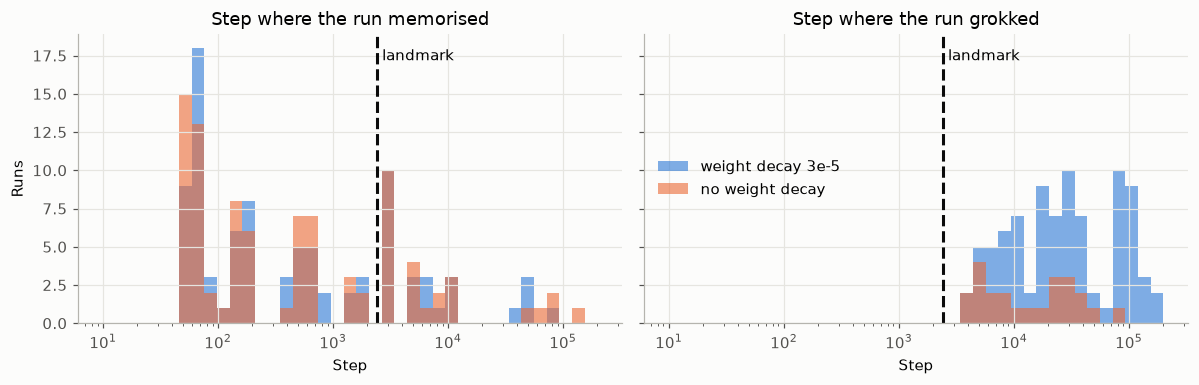

In [10]:
bins = np.logspace(1, np.log10(200_000), 40)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, col, title in [(axes[0], 't_mem99', 'Step where the run memorised'),
                       (axes[1], 't_gen95', 'Step where the run grokked')]:
    for label, df in sets.items():
        ax.hist(df[col].dropna(), bins=bins, color=colours[label], alpha=0.6, label=label)
    ax.axvline(LANDMARK, color=INK, linestyle='--')
    ax.text(LANDMARK, 0.95, ' landmark', transform=ax.get_xaxis_transform(), va='top')
    ax.set_xscale('log')
    ax.set_xlabel('Step')
    ax.set_title(title)
axes[0].set_ylabel('Runs')
axes[1].legend(loc='center left')
plt.tight_layout()
plt.show()

**Takeaway.** Many runs memorise before the landmark (65 of 90 in each group), but none groks before it. So the kernel at the landmark can't contain the answer. This is also why we count `T` from step 0. A gap counted from memorisation would already have started for some runs and not for others.

### Seeds of one cell are near twins

Each dot below is one seed with weight decay 3e-5, and each column is one cell.

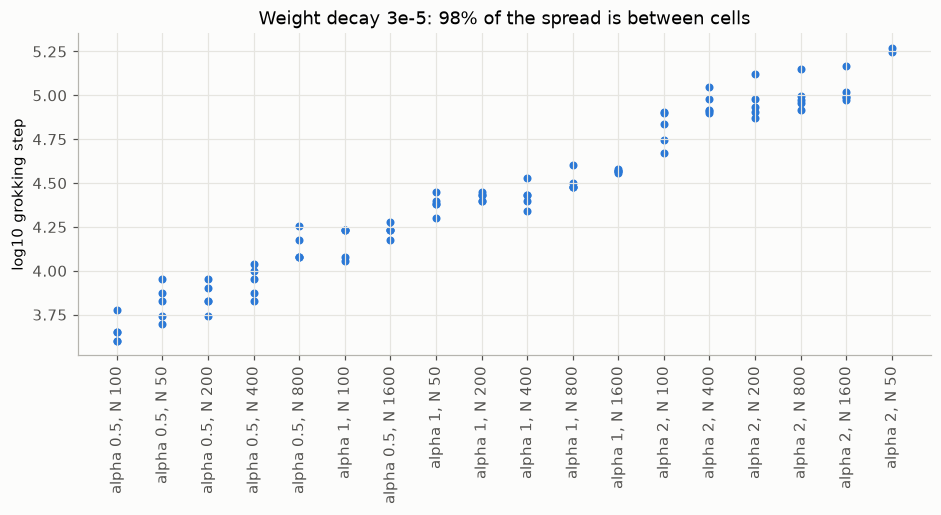

In [11]:
seen = wd[wd['grokked'] == 1].copy()
seen['log10 T'] = np.log10(seen['T'])
seen['name'] = 'alpha ' + seen['alpha'].map('{:g}'.format) + ', N ' + seen['width'].astype(str)
order = seen.groupby('name')['log10 T'].mean().sort_values().index
share = seen.groupby('name')['log10 T'].transform('mean').var() / seen['log10 T'].var()

fig, ax = plt.subplots(figsize=(10, 3.8))
for i, name in enumerate(order):
    y = seen.loc[seen['name'] == name, 'log10 T']
    ax.scatter(np.full(len(y), i), y, color=WD_COLOUR, s=18)
ax.set_xticks(range(len(order)), order, rotation=90)
ax.set_ylabel('log10 grokking step')
ax.set_title(f'Weight decay 3e-5: {share:.0%} of the spread is between cells')
plt.show()

**Takeaway.** The seeds of a cell sit almost on top of each other. So we can't test a model on a seed whose cell-mates it has already seen. That would be like checking an exam answer against a copy of itself. Every score below **holds out one whole cell at a time**: we fit on all the other cells and predict the held-out one.

## Part 5. The ladder of models

We try four models, from the simplest up. Each one gets three sets of inputs.

- **settings**: `alpha` and width, as yes/no columns.
- **kernel**: `A_t`, `S_t` and `R_t` at the landmark.
- **both**: settings and kernel together.

If the kernel tells us something the settings don't, **both** should beat **settings**.

| Step | Model | Predicts | Runs it uses | Score |
| --- | --- | --- | --- | --- |
| 1 | Linear regression | log `T` | grokked runs only | concordance |
| 2 | Logistic regression | groks within the budget, yes or no | all | AUC |
| 3 | AFT | log `T` | all, with censored runs as "over 200,000" | concordance |
| 4 | Cox | the chance of grokking at the next step | all | concordance |

**Concordance** takes every pair of runs where we know which grokked first, and counts how often the model orders them right. **AUC** is the chance that a run that grokked gets a higher score than one that didn't. For both, 0.5 is a coin toss and 1 is perfect.

The picture below is the reason the ladder exists. Some runs never grok, so we only know a lower limit for their `T`.

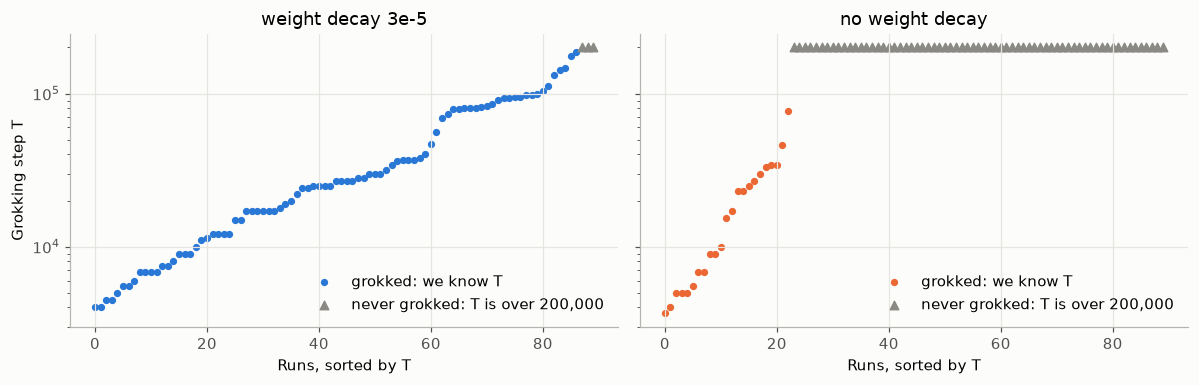

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (label, df) in zip(axes, sets.items()):
    d = df.sort_values('T').reset_index(drop=True)
    seen_T = d['grokked'] == 1
    ax.scatter(d.index[seen_T], d.loc[seen_T, 'T'], color=colours[label], s=14, label='grokked: we know T')
    ax.scatter(d.index[~seen_T], d.loc[~seen_T, 'T'], color=GREY, marker='^', s=30,
               label='never grokked: T is over 200,000')
    ax.set_yscale('log')
    ax.set_xlabel('Runs, sorted by T')
    ax.set_title(label)
    ax.legend(loc='lower right')
axes[0].set_ylabel('Grokking step T')
plt.tight_layout()
plt.show()

## Part 6. Step 1: linear regression

The simplest model is a straight line through log `T`. It needs a real `T`, so it has to **drop every run that never grokked**. Keep that weakness in mind.

The loop holds out one cell at a time. The kernel numbers are standardised with the training runs only. `scores` collects every held-out score in this notebook.

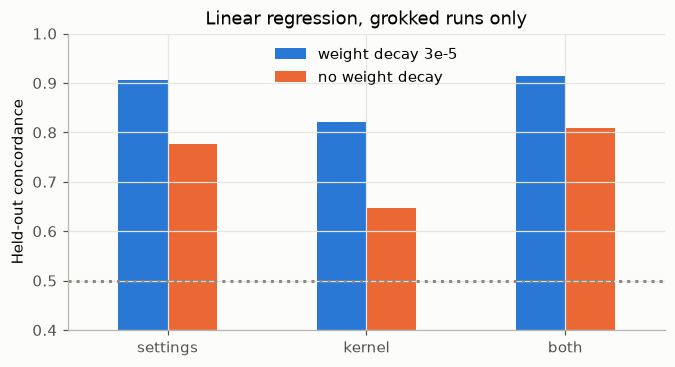

,weight decay 3e-5,no weight decay
settings,0.906,0.777
kernel,0.822,0.648
both,0.915,0.810


In [13]:
INPUTS = ['settings', 'kernel', 'both']
scores = {}

for label, df in sets.items():
    g = df[df['grokked'] == 1].copy()
    dummies = pd.get_dummies(g[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
    for cell in g['cell'].unique():
        train, test = g['cell'] != cell, g['cell'] == cell
        z = (g[kernel] - g.loc[train, kernel].mean()) / g.loc[train, kernel].std()
        for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
            line = LinearRegression().fit(X[train], np.log10(g.loc[train, 'T']))
            g.loc[test, f'lin_{inputs}'] = line.predict(X[test])
    for inputs in INPUTS:
        scores[(label, 'linear regression', inputs)] = concordance_index(g['T'], g[f'lin_{inputs}'])

lin = pd.DataFrame({label: [scores[(label, 'linear regression', i)] for i in INPUTS] for label in sets}, index=INPUTS)
ax = lin.plot.bar(color=[colours[l] for l in lin.columns], rot=0, ylim=(0.4, 1), figsize=(7, 3.5))
ax.axhline(0.5, color=GREY, linestyle=':')
ax.set_ylabel('Held-out concordance')
ax.set_title('Linear regression, grokked runs only')
plt.show()
lin.round(3)

**Takeaway.**

- With weight decay 3e-5, the kernel helps a little: 0.906 with the settings and 0.915 with both.
- Without weight decay, adding the kernel helps too, 0.777 to 0.810. But once the censored runs are dropped, only 23 runs in 5 cells are left. Three more numbers on so few runs make this score shaky.

## Part 7. Step 2: logistic regression

Next we keep every run but ask a simpler question: **will it grok within the budget, yes or no?** Logistic regression gives each run a probability of grokking.

This works for no weight decay only. With weight decay 3e-5 only 3 runs fail, all in one cell. When that cell is held out, the model has no failed runs left to learn from.

In [14]:
df = no_wd
dummies = pd.get_dummies(df[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
for cell in df['cell'].unique():
    train, test = df['cell'] != cell, df['cell'] == cell
    z = (df[kernel] - df.loc[train, kernel].mean()) / df.loc[train, kernel].std()
    for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
        clf = LogisticRegression(max_iter=1000).fit(X[train], df.loc[train, 'grokked'])
        df.loc[test, f'prob_{inputs}'] = clf.predict_proba(X[test])[:, 1]

rows = {}
for inputs in INPUTS:
    scores[(NO_WD_LABEL, 'logistic regression', inputs)] = roc_auc_score(df['grokked'], df[f'prob_{inputs}'])
    rows[inputs] = {'AUC': scores[(NO_WD_LABEL, 'logistic regression', inputs)],
                    'balanced accuracy': balanced_accuracy_score(df['grokked'], df[f'prob_{inputs}'] > 0.5)}
pd.DataFrame(rows).T.round(3)

,AUC,balanced accuracy
settings,0.855,0.680
kernel,0.951,0.833
both,0.982,0.797


**Balanced accuracy** averages the hit rate on grokked runs and on the others, so always guessing "no" scores 0.5. A **confusion matrix** counts the right and wrong guesses, with a cut at probability 0.5.

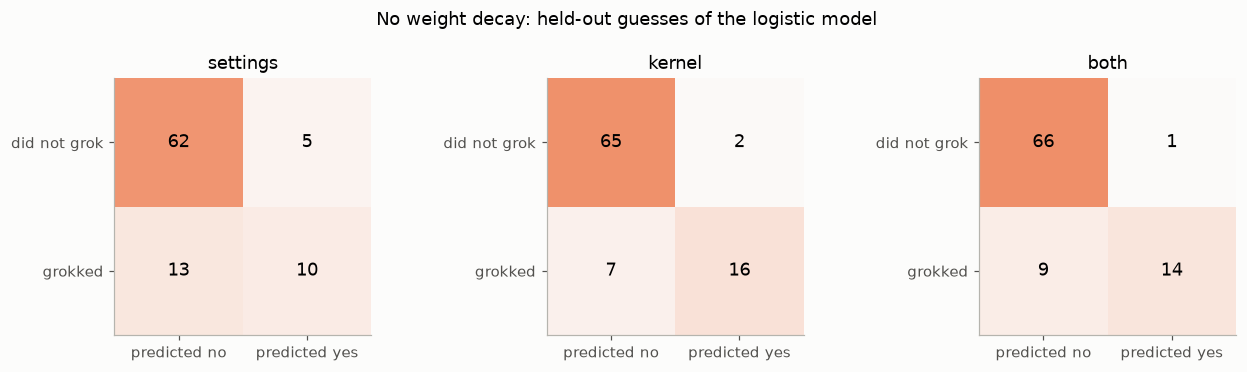

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, inputs in zip(axes, INPUTS):
    guess = (df[f'prob_{inputs}'] > 0.5).astype(int)
    matrix = pd.crosstab(df['grokked'], guess).reindex(index=[0, 1], columns=[0, 1], fill_value=0).to_numpy()
    ax.imshow(matrix, cmap=LinearSegmentedColormap.from_list('n', [SURFACE, NO_WD_COLOUR]), vmin=0, vmax=len(df))
    for i in range(2):
        for j in range(2):
            ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=12)
    ax.set_xticks([0, 1], ['predicted no', 'predicted yes'])
    ax.set_yticks([0, 1], ['did not grok', 'grokked'])
    ax.set_title(inputs)
    ax.grid(False)
fig.suptitle('No weight decay: held-out guesses of the logistic model')
plt.tight_layout()
plt.show()

**Takeaway.**

- Without weight decay, the kernel predicts whether a run groks better than the settings do. Its AUC is 0.951 against 0.855, and the two together reach 0.982.
- The settings model misses 13 of the 23 runs that grok. It can't tell which small cells will make it, and the kernel at the landmark already can.

## Part 8. Step 3: the AFT model

Linear regression drops the runs that never grok. Logistic regression keeps them but forgets the timing. The **accelerated failure time (AFT)** model does both jobs (report Eq. 10 and 11).

It's a linear regression on log `T` with one upgrade. When a run grokked, we know `T`, and the model fits it like normal regression. When it didn't, we only know `T` is over 200,000, and the model uses exactly that: it asks for a line that makes "over 200,000" likely for that run. Each input stretches or squeezes the time. A coefficient `a` multiplies the median grokking step by e^a, so a negative `a` means sooner.

A tiny penalty (0.01) keeps the fit stable when a setting has no grokked run at all, like `alpha` 2 without weight decay.

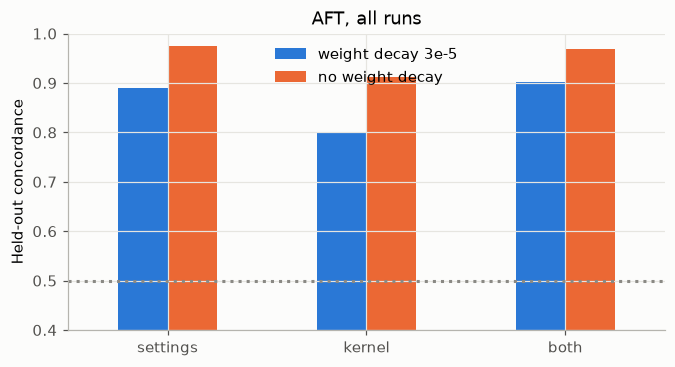

,weight decay 3e-5,no weight decay
settings,0.890,0.974
kernel,0.800,0.912
both,0.902,0.969


In [16]:
for label, df in sets.items():
    dummies = pd.get_dummies(df[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
    for cell in df['cell'].unique():
        train, test = df['cell'] != cell, df['cell'] == cell
        z = (df[kernel] - df.loc[train, kernel].mean()) / df.loc[train, kernel].std()
        for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
            aft = LogNormalAFTFitter(penalizer=0.01).fit(X[train].assign(T=df['T'], grokked=df['grokked']), 'T', 'grokked')
            df.loc[test, f'aft_{inputs}'] = aft.predict_median(X[test]).to_numpy().ravel()
    for inputs in INPUTS:
        scores[(label, 'AFT', inputs)] = concordance_index(df['T'], df[f'aft_{inputs}'], df['grokked'])

aft_scores = pd.DataFrame({label: [scores[(label, 'AFT', i)] for i in INPUTS] for label in sets}, index=INPUTS)
ax = aft_scores.plot.bar(color=[colours[l] for l in aft_scores.columns], rot=0, ylim=(0.4, 1), figsize=(7, 3.5))
ax.axhline(0.5, color=GREY, linestyle=':')
ax.set_ylabel('Held-out concordance')
ax.set_title('AFT, all runs')
plt.show()
aft_scores.round(3)

**Takeaway.**

- With weight decay 3e-5, the kernel adds a little to the settings: 0.890 with the settings and 0.902 with both.
- Without weight decay, the settings alone reach 0.974, and the kernel can't improve on that (0.969).

### Which kernel numbers matter in the AFT?

Now we fit the **both** model on every run and read the three kernel coefficients. The **likelihood ratio test** asks whether the three numbers together improve on the settings alone. A small p-value says yes.

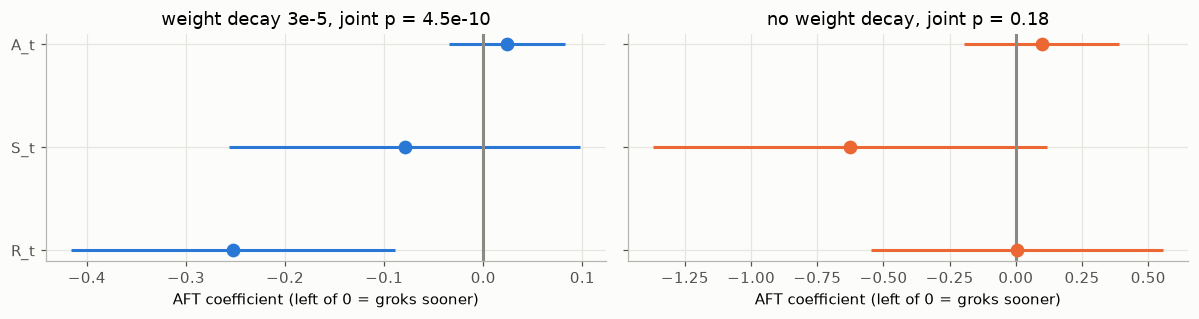

coef  coef lower 95%  coef upper 95%      p  \
                  covariate                                                 
weight decay 3e-5 A_t        0.024          -0.034           0.083  0.416   
                  S_t       -0.079          -0.256           0.098  0.381   
                  R_t       -0.253          -0.416          -0.089  0.002   
no weight decay   A_t        0.097          -0.196           0.391  0.517   
                  S_t       -0.626          -1.370           0.118  0.099   
                  R_t        0.003          -0.548           0.554  0.991   

                             times the median  
                  covariate                    
weight decay 3e-5 A_t                   1.025  
                  S_t                   0.924  
                  R_t                   0.777  
no weight decay   A_t                   1.102  
                  S_t                   0.535  
                  R_t                   1.003

In [17]:
coef_tables, lr_p = {}, {}
for label, df in sets.items():
    dummies = pd.get_dummies(df[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
    z = (df[kernel] - df[kernel].mean()) / df[kernel].std()
    with_kernel = LogNormalAFTFitter(penalizer=0.01).fit(dummies.join(z).assign(T=df['T'], grokked=df['grokked']), 'T', 'grokked')
    without = LogNormalAFTFitter(penalizer=0.01).fit(dummies.assign(T=df['T'], grokked=df['grokked']), 'T', 'grokked')
    lr_p[label] = chi2.sf(2 * (with_kernel.log_likelihood_ - without.log_likelihood_), 3)
    coef_tables[label] = with_kernel.summary.loc['mu_'].loc[kernel, ['coef', 'coef lower 95%', 'coef upper 95%', 'p']]
coefs = pd.concat(coef_tables)
coefs['times the median'] = np.exp(coefs['coef'])

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, label in zip(axes, sets):
    c = coefs.loc[label]
    ax.errorbar(c['coef'], range(3), xerr=[c['coef'] - c['coef lower 95%'], c['coef upper 95%'] - c['coef']],
                fmt='o', markersize=8, color=colours[label])
    ax.axvline(0, color=GREY)
    ax.set_yticks(range(3), kernel)
    ax.set_xlabel('AFT coefficient (left of 0 = groks sooner)')
    ax.set_title(f'{label}, joint p = {lr_p[label]:.2g}')
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()
coefs.round(3)

**Takeaway.**

- With weight decay 3e-5, the three numbers together clearly help (p = 5e-10). `R_t` carries the signal. One standard deviation more rotation goes with a grokking step about 22 percent shorter (0.78 times the median).
- Without weight decay, no single number stands out and the joint test is weak (p = 0.18).
- These intervals count each seed as an independent run, so they are a bit too narrow.

## Part 9. Step 4: the Cox model

The Cox model doesn't predict a time. At every step it looks at the runs that haven't grokked yet and asks which one is most likely to grok next. That chance is the **hazard**. Each input multiplies the hazard by e^γ. So a **positive** γ means sooner, which is the opposite sign to the AFT (report Eq. 13 and 14).

We use it three ways.

- **(a)** With the kernel at the landmark, scored on held-out cells like the other models.
- **(b)** The report's own version, where the kernel changes along the run.
- **(c)** An extra that isn't in the report. It compares only the seeds of one cell, so the settings drop out.

### (a) The kernel at the landmark

In [18]:
for label, df in sets.items():
    dummies = pd.get_dummies(df[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
    for cell in df['cell'].unique():
        train, test = df['cell'] != cell, df['cell'] == cell
        z = (df[kernel] - df.loc[train, kernel].mean()) / df.loc[train, kernel].std()
        for inputs, X in [('settings', dummies), ('kernel', z), ('both', dummies.join(z))]:
            cox = CoxPHFitter(penalizer=0.01).fit(X[train].assign(T=df['T'], grokked=df['grokked']), 'T', 'grokked')
            df.loc[test, f'cox_{inputs}'] = cox.predict_partial_hazard(X[test]).to_numpy().ravel()
    for inputs in INPUTS:
        # a higher hazard means sooner, so we flip its sign before scoring
        scores[(label, 'Cox', inputs)] = concordance_index(df['T'], -df[f'cox_{inputs}'], df['grokked'])

pd.DataFrame({label: [scores[(label, 'Cox', i)] for i in INPUTS] for label in sets}, index=INPUTS).round(3)

,weight decay 3e-5,no weight decay
settings,0.893,0.974
kernel,0.882,0.913
both,0.914,0.965


**Takeaway.** The landmark Cox model tells the same story as the AFT. The kernel adds a little with weight decay 3e-5 (0.893 to 0.914) and nothing without it (0.974 to 0.965).

### (b) The report's model: the kernel at every step

Here the kernel can change along the run (report Eq. 13). We cut each run into stretches between the saved steps. Each stretch carries the kernel from its start, so the model never sees the future. The report calls this left-continuous. A stretch gets `event` = 1 if the run groks inside it. We start at the landmark and fit each grokking level of the report: 0.80, 0.90 and 0.95.

In [19]:
long = kern.merge(data[['run_id', 'last_step', 't_gen80', 't_gen90', 't_gen95']], on='run_id').sort_values(['run_id', 'step'])
long['start'] = long['step']
long['next'] = long.groupby('run_id')['step'].shift(-1)     # the next saved step of the same run
long = long.dropna(subset=['next'])

tv_rows, tv_fits, tv_pen_rows = {}, {}, {}
for label, df in sets.items():
    for level in ['t_gen80', 't_gen90', 't_gen95']:
        lf = long[long['run_id'].isin(df['run_id'])].copy()
        lf['grokked'] = lf[level].notna().astype(int)
        lf['T'] = lf[level].fillna(lf['last_step'])
        lf = lf[(lf['start'] >= LANDMARK) & (lf['start'] < lf['T'])]      # from the landmark until the run groks
        lf['stop'] = np.minimum(lf['next'], lf['T'])
        lf['event'] = ((lf['stop'] == lf['T']) & (lf['grokked'] == 1)).astype(int)
        assert lf['event'].sum() == lf.groupby('run_id')['grokked'].first().sum()   # one event per grokked run
        at_lm = lf[lf['start'] == LANDMARK]
        lf[kernel] = (lf[kernel] - at_lm[kernel].mean()) / at_lm[kernel].std()
        cols = dict(id_col='run_id', event_col='event', start_col='start', stop_col='stop')
        stretches = lf[['run_id', 'start', 'stop', 'event'] + kernel]
        # The report's model has no penalty. It has no finite estimate when one number splits the runs that grok
        # from the rest, so a failed fit is recorded, not hidden.
        try:
            ctv = CoxTimeVaryingFitter().fit(stretches, **cols)
            tv_fits[(label, level)] = ctv.summary
            tv_rows[(label, level)] = {**ctv.summary['coef'].to_dict(), **ctv.summary['p'].add_prefix('p ').to_dict(),
                                       'joint p': ctv.log_likelihood_ratio_test().p_value, 'fit': 'ok'}
        except Exception as error:
            tv_rows[(label, level)] = {'fit': f'no finite estimate ({type(error).__name__})'}
        # The check: the same model with a small ridge penalty, which always has a finite estimate.
        pen = CoxTimeVaryingFitter(penalizer=0.01).fit(stretches, **cols)
        tv_pen_rows[(label, level)] = {**pen.summary['coef'].to_dict(), **pen.summary['p'].add_prefix('p ').to_dict()}

lf[['run_id', 'start', 'stop', 'event'] + kernel].head()

/Users/zer0/Documents/Documents/courses/project/STAT3007/.venv/lib/python3.14/site-packages/lifelines/fitters/cox_time_varying_fitter.py:526: RuntimeWarning: overflow encountered in exp
  phi_i = weights_at_t * np.exp(np.dot(X_at_t, beta))
/Users/zer0/Documents/Documents/courses/project/STAT3007/.venv/lib/python3.14/site-packages/lifelines/fitters/cox_time_varying_fitter.py:526: RuntimeWarning: overflow encountered in exp
  phi_i = weights_at_t * np.exp(np.dot(X_at_t, beta))


,run_id,start,stop,event,A_t,S_t,R_t
5784,ntk_N100_a0.5_wd0_s0,2430,3305.0,0,-0.262540,2.573234,1.766967
5785,ntk_N100_a0.5_wd0_s0,3305,3662.0,1,0.136873,3.651916,2.101328
5832,ntk_N100_a0.5_wd0_s1,2430,3305.0,0,-1.927761,2.639705,1.310607
5833,ntk_N100_a0.5_wd0_s1,3305,4496.0,0,-2.034014,3.868811,1.544330
5834,ntk_N100_a0.5_wd0_s1,4496,4981.0,1,-2.120143,4.960780,1.672419


Above are the first stretches of one run. Below are the fits.

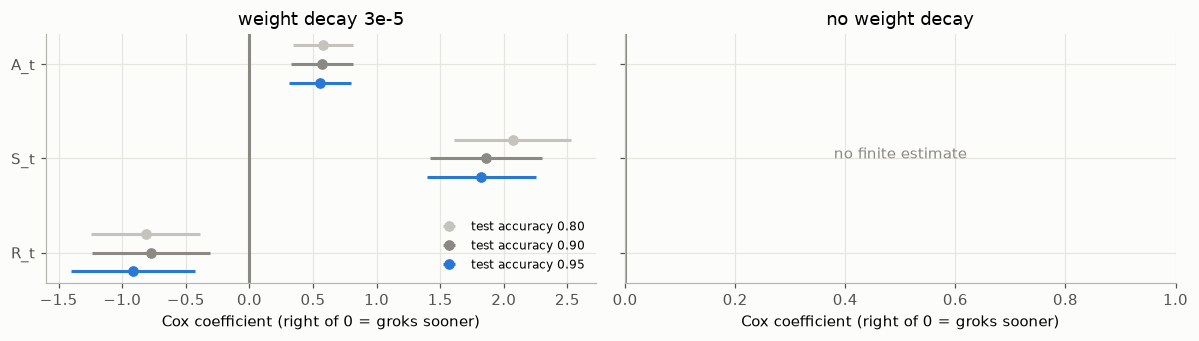

A_t       S_t       R_t     p A_t p S_t  \
weight decay 3e-5 t_gen80  0.577479  2.068764 -0.816409  0.000002   0.0   
                  t_gen90  0.568751  1.860818 -0.774745  0.000005   0.0   
                  t_gen95  0.553455  1.823635 -0.916273  0.000008   0.0   
no weight decay   t_gen80       NaN       NaN       NaN       NaN   NaN   
                  t_gen90       NaN       NaN       NaN       NaN   NaN   
                  t_gen95       NaN       NaN       NaN       NaN   NaN   

                              p R_t joint p  \
weight decay 3e-5 t_gen80  0.000202     0.0   
                  t_gen90  0.001113     0.0   
                  t_gen95  0.000239     0.0   
no weight decay   t_gen80       NaN     NaN   
                  t_gen90       NaN     NaN   
                  t_gen95       NaN     NaN   

                                                             fit  
weight decay 3e-5 t_gen80                                     ok  
                  t_gen90                                     ok  
                  t_gen95                                     ok  
no weight decay   t_gen80       no finite estimate (LinAlgError)  
                  t_gen90  no finite estimate (ConvergenceError)  
                  t_gen95  no finite estimate (ConvergenceError)

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, label in zip(axes, sets):
    for k, (level, shade) in enumerate([('t_gen80', '#c4c3bd'), ('t_gen90', GREY), ('t_gen95', colours[label])]):
        if (label, level) not in tv_fits:    # no finite estimate, see the table
            continue
        s = tv_fits[(label, level)]
        ax.errorbar(s['coef'], np.arange(3) + 0.2 * (k - 1),
                    xerr=[s['coef'] - s['coef lower 95%'], s['coef upper 95%'] - s['coef']],
                    fmt='o', color=shade, label=f'test accuracy 0.{level[-2:]}')
    ax.axvline(0, color=GREY)
    ax.set_yticks(range(3), kernel)
    ax.set_xlabel('Cox coefficient (right of 0 = groks sooner)')
    ax.set_title(label)
axes[0].invert_yaxis()
axes[0].legend(loc='lower right', fontsize=8)
for ax, label in zip(axes, sets):
    if not any((label, level) in tv_fits for level in ['t_gen80', 't_gen90', 't_gen95']):
        ax.text(0.5, 0.5, 'no finite estimate', transform=ax.transAxes, ha='center', color=GREY)
plt.tight_layout()
plt.show()
pd.DataFrame(tv_rows).T.round(3)

**The check with a penalty.** The report's model has no penalty. Below is the same model with a small ridge penalty of 0.01, which always gives a finite answer. It is a check and is not in the report. Where the report's model has no finite estimate, this table shows which way the numbers point.

In [21]:
pd.DataFrame(tv_pen_rows).T.round(3)

A_t    S_t    R_t  p A_t  p S_t  p R_t
weight decay 3e-5 t_gen80  0.501  1.439 -0.348  0.000    0.0  0.014
                  t_gen90  0.505  1.241 -0.269  0.000    0.0  0.050
                  t_gen95  0.496  1.150 -0.309  0.000    0.0  0.024
no weight decay   t_gen80 -0.065  0.965  0.133  0.617    0.0  0.343
                  t_gen90 -0.123  0.835  0.114  0.357    0.0  0.418
                  t_gen95 -0.124  0.578  0.202  0.354    0.0  0.145

**Takeaway.**

- With weight decay 3e-5, at every level the three numbers together are clearly linked to grokking (joint p below 0.001). `S_t` has the clearest effect: a run whose kernel has grown more is closer to grokking. Higher `A_t` also goes with grokking sooner, and higher `R_t` with grokking later.
- Without weight decay, the report's model has no finite estimate at any level. The fit fails to converge whenever `R_t` is in it. This usually means one number almost splits the runs that grok from the rest. Only 23 to 29 of the 90 runs grok here, depending on the level.
- The check with a penalty gives the direction. Without weight decay only `S_t` has a clear link (p below 0.001), and `A_t` and `R_t` do not.
- Be careful with this model. It reads the kernel up to the step before grokking, so it shows the kernel moving while the run groks. That describes the run and gives no early warning. The landmark models are the early warnings. The report adds (§3.5) that the run itself produces these numbers, so the model says nothing about cause.

### (c) Extra: inside one cell

This Cox model gets one **stratum** per cell. Each cell has its own baseline, and the model only compares seeds of the same cell. So the settings drop out completely, and we see whether a seed with a higher kernel number groks sooner than its cell-mates.

In [22]:
rows = {}
for label, df in sets.items():
    z = (df[kernel] - df[kernel].mean()) / df[kernel].std()
    cox = CoxPHFitter().fit(df[['T', 'grokked', 'cell']].join(z), 'T', 'grokked', strata='cell', robust=True)
    rows[label] = {**cox.summary['coef'].add_prefix('coef ').to_dict(), **cox.summary['p'].add_prefix('p ').to_dict(),
                   'joint p': cox.log_likelihood_ratio_test().p_value}
pd.DataFrame(rows).T.round(3)

,coef A_t,coef S_t,coef R_t,p A_t,p S_t,p R_t,joint p
weight decay 3e-5,-0.010,0.943,-0.443,0.941,0.399,0.410,0.897
no weight decay,-0.087,-0.230,0.704,0.726,0.810,0.289,0.803


A picture of the same idea, for the runs that grokked. Each dot is one seed. Its position shows how far its `A_t` and its grokking step sit above or below the average of its cell-mates.

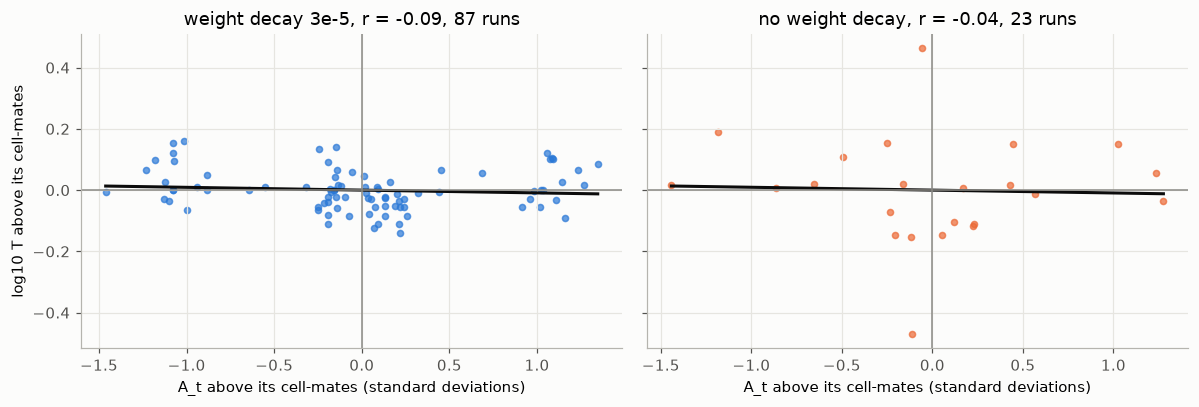

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (label, df) in zip(axes, sets.items()):
    g = df[df['grokked'] == 1].copy()
    g = g[g.groupby('cell')['T'].transform('size') >= 2]
    z = (g['A_t'] - df['A_t'].mean()) / df['A_t'].std()
    x = z - z.groupby(g['cell']).transform('mean')
    y = np.log10(g['T']) - np.log10(g['T']).groupby(g['cell']).transform('mean')
    slope, intercept = np.polyfit(x, y, 1)
    ax.scatter(x, y, color=colours[label], s=16, alpha=0.7)
    ax.plot(np.sort(x), intercept + slope * np.sort(x), color=INK)
    ax.axhline(0, color=GREY, linewidth=1)
    ax.axvline(0, color=GREY, linewidth=1)
    ax.set_xlabel('A_t above its cell-mates (standard deviations)')
    ax.set_title(f'{label}, r = {np.corrcoef(x, y)[0, 1]:.2f}, {len(g)} runs')
axes[0].set_ylabel('log10 T above its cell-mates')
plt.tight_layout()
plt.show()

**Takeaway.** Inside a cell, the kernel numbers say nothing about which seed groks first. The joint p-values are 0.90 and 0.80, and the dots have almost no slope (r = -0.09 and -0.04). So whatever the kernel adds comes from telling cells apart. It can't rank the near twins inside a cell.

## Part 10. The four models side by side

First, every held-out score from Parts 6 to 9 in one table and one picture. Logistic regression is scored by AUC and the others by concordance. For both, 0.5 is a coin toss.

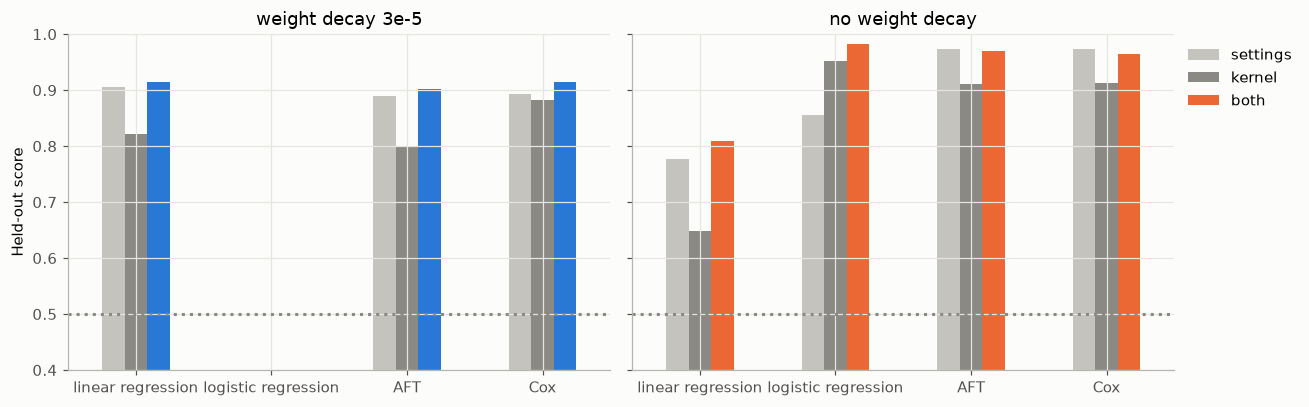

settings  kernel   both
no weight decay   AFT                     0.974   0.912  0.969
                  Cox                     0.974   0.913  0.965
                  linear regression       0.777   0.648  0.810
                  logistic regression     0.855   0.951  0.982
weight decay 3e-5 AFT                     0.890   0.800  0.902
                  Cox                     0.893   0.882  0.914
                  linear regression       0.906   0.822  0.915

In [24]:
models = ['linear regression', 'logistic regression', 'AFT', 'Cox']
table = pd.Series(scores).unstack()[INPUTS]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, label in zip(axes, sets):
    t = table.loc[label].reindex(models)
    t.plot.bar(ax=ax, rot=0, color=['#c4c3bd', GREY, colours[label]], ylim=(0.4, 1), legend=False)
    ax.axhline(0.5, color=GREY, linestyle=':')
    ax.set_title(label)
axes[0].set_ylabel('Held-out score')
axes[1].legend(axes[1].containers, INPUTS, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
table.round(3)

### Which of `A_t`, `S_t` and `R_t` predicts?

Now each number goes in on its own, in every model. **Alone** shows everything the number knows, including what it knows about the settings. **On top of the settings** shows what it adds beyond them. The loop is the same hold-out loop as above. It takes about a minute.

In [25]:
one = {}
for label, df in sets.items():
    dummies = pd.get_dummies(df[['alpha', 'width']].astype('category'), drop_first=True, dtype=float)
    grok = df['grokked'] == 1
    for number in kernel:
        for how in ['alone', 'on top of the settings']:
            pred = pd.DataFrame(index=df.index, columns=models, dtype=float)
            for cell in df['cell'].unique():
                train, test = df['cell'] != cell, df['cell'] == cell
                z = (df[[number]] - df.loc[train, [number]].mean()) / df.loc[train, [number]].std()
                X = z if how == 'alone' else dummies.join(z)
                fit_on = X[train].assign(T=df['T'], grokked=df['grokked'])
                if (test & grok).any():
                    line = LinearRegression().fit(X[train & grok], np.log10(df.loc[train & grok, 'T']))
                    pred.loc[test & grok, 'linear regression'] = line.predict(X[test & grok])
                if label == NO_WD_LABEL:    # see Part 7 for why 3e-5 gets no logistic model
                    clf = LogisticRegression(max_iter=1000).fit(X[train], df.loc[train, 'grokked'])
                    pred.loc[test, 'logistic regression'] = clf.predict_proba(X[test])[:, 1]
                aft = LogNormalAFTFitter(penalizer=0.01).fit(fit_on, 'T', 'grokked')
                pred.loc[test, 'AFT'] = aft.predict_median(X[test]).to_numpy().ravel()
                cox = CoxPHFitter(penalizer=0.01).fit(fit_on, 'T', 'grokked')
                pred.loc[test, 'Cox'] = -cox.predict_partial_hazard(X[test]).to_numpy().ravel()
            one[(label, how, number)] = {
                'linear regression': concordance_index(df.loc[grok, 'T'], pred.loc[grok, 'linear regression']),
                'logistic regression': roc_auc_score(df['grokked'], pred['logistic regression']) if label == NO_WD_LABEL else np.nan,
                'AFT': concordance_index(df['T'], pred['AFT'], df['grokked']),
                'Cox': concordance_index(df['T'], pred['Cox'], df['grokked'])}
one = pd.DataFrame(one).T.sort_index()
one.round(3)

linear regression  \
no weight decay   alone                  A_t              0.231   
                                         R_t              0.636   
                                         S_t              0.688   
                  on top of the settings A_t              0.761   
                                         R_t              0.798   
                                         S_t              0.765   
weight decay 3e-5 alone                  A_t              0.457   
                                         R_t              0.677   
                                         S_t              0.837   
                  on top of the settings A_t              0.904   
                                         R_t              0.923   
                                         S_t              0.921   

                                              logistic regression    AFT  \
no weight decay   alone                  A_t                0.757  0.728   
                                         R_t                0.971  0.936   
                                         S_t                0.711  0.820   
                  on top of the settings A_t                0.874  0.974   
                                         R_t                0.987  0.966   
                                         S_t                0.889  0.974   
weight decay 3e-5 alone                  A_t                  NaN  0.436   
                                         R_t                  NaN  0.656   
                                         S_t                  NaN  0.810   
                  on top of the settings A_t                  NaN  0.885   
                                         R_t                  NaN  0.914   
                                         S_t                  NaN  0.906   

                                                Cox  
no weight decay   alone                  A_t  0.785  
                                         R_t  0.943  
                                         S_t  0.889  
                  on top of the settings A_t  0.942  
                                         R_t  0.942  
                                         S_t  0.975  
weight decay 3e-5 alone                  A_t  0.482  
                                         R_t  0.770  
                                         S_t  0.872  
                  on top of the settings A_t  0.894  
                                         R_t  0.918  
                                         S_t  0.921

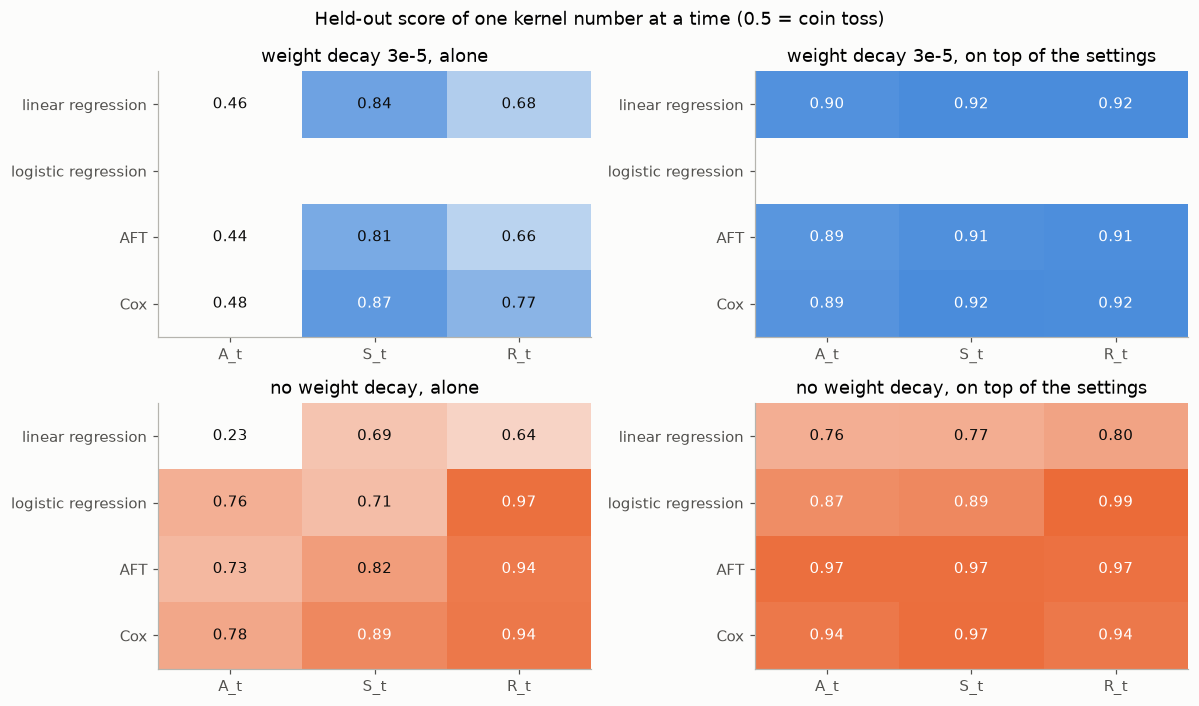

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for i, label in enumerate(sets):
    for j, how in enumerate(['alone', 'on top of the settings']):
        m = one.loc[(label, how)].T.reindex(index=models, columns=kernel)
        ax = axes[i, j]
        ax.imshow(m, cmap=LinearSegmentedColormap.from_list('s', [SURFACE, colours[label]]), vmin=0.5, vmax=1, aspect='auto')
        for r in range(m.shape[0]):
            for c in range(m.shape[1]):
                v = m.iloc[r, c]
                ax.text(c, r, '' if np.isnan(v) else f'{v:.2f}', ha='center', va='center',
                        color='white' if v > 0.85 else INK)
        ax.set_xticks(range(3), kernel)
        ax.set_yticks(range(len(models)), models)
        ax.set_title(f'{label}, {how}')
        ax.grid(False)
fig.suptitle('Held-out score of one kernel number at a time (0.5 = coin toss)')
plt.tight_layout()
plt.show()

**Takeaway.**

- **The model matters less than the data.** With weight decay 3e-5, linear regression, the AFT and the Cox model give about the same scores, and each gains 0.01 to 0.02 from the kernel. Without weight decay, linear regression does worst, because it has to drop the 67 runs that never grok.
- **Alone,** `S_t` is the best number with weight decay 3e-5 (0.81 to 0.87), and `R_t` is the best without it in the logistic, AFT and Cox models (0.94 to 0.97). In linear regression without weight decay, `S_t` is best. With weight decay, `A_t` alone is no better than a coin toss, and all its scores fall below 0.5. That happens when a number carries almost no signal and we hold out one cell at a time.
- **On top of the settings,** with weight decay 3e-5, `R_t` and `S_t` each add 0.01 to 0.03 and `A_t` adds nothing. Without weight decay, no single number improves the AFT.

## Part 11. Do we need more runs without weight decay?

Without weight decay few cells have a grokked run. Below are the grokked seeds and the median test accuracy at step 200,000 of each cell.

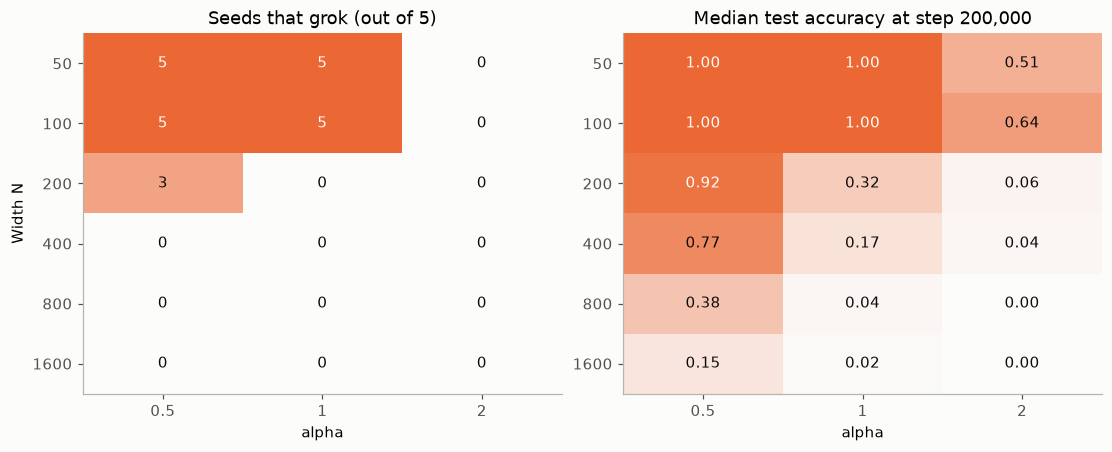

In [27]:
final = {'Seeds that grok (out of 5)': no_wd.pivot_table(index='width', columns='alpha', values='grokked', aggfunc='sum'),
         'Median test accuracy at step 200,000': no_wd.pivot_table(index='width', columns='alpha', values='test_acc_final', aggfunc='median')}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
for ax, (title, m), top in zip(axes, final.items(), [5, 1]):
    ax.imshow(m, cmap=LinearSegmentedColormap.from_list('n', [SURFACE, NO_WD_COLOUR]), vmin=0, vmax=top, aspect='auto')
    for r in range(m.shape[0]):
        for c in range(m.shape[1]):
            v = m.iloc[r, c]
            ax.text(c, r, f'{v:g}' if top == 5 else f'{v:.2f}', ha='center', va='center',
                    color='white' if v > 0.8 * top else INK)
    ax.set_xticks(range(3), ['0.5', '1', '2'])
    ax.set_yticks(range(m.shape[0]), m.index)
    ax.set_xlabel('alpha')
    ax.set_title(title)
    ax.grid(False)
axes[0].set_ylabel('Width N')
plt.show()

**Takeaway.**

- Some censored cells are close to grokking. `alpha` 0.5 at widths 200 and 400 ends at 0.92 and 0.77, and `alpha` 2 at widths 50 and 100 ends at 0.51 and 0.64. A longer budget would likely turn some of these into grokked runs.
- The wide networks at `alpha` 1 and 2 end near 0. A longer budget is unlikely to help them.
- Only 5 cells have a grokked run without weight decay, which is thin for any model. More seeds won't fix that, because the seeds of a cell are near copies. More cells near the edge, or a longer budget for the close cells, would.

## Summary

| Part | What we found |
| --- | --- |
| 1 and 2 | With weight decay 3e-5, 87 of 90 runs grok. Without it 23 do, all at small width and small `alpha`. A bigger `alpha` means a later grokking step. |
| 3 | The rebuilt kernel matches report Table 2. The two groups look alike until grokking and split after it. |
| 4 | No run groks before the landmark. 98% of the spread in log `T` lies between cells. |
| 6 to 9 | With weight decay 3e-5, the kernel adds 0.01 to 0.02 of held-out concordance in every time model. Without weight decay it adds nothing to the AFT or the Cox model, and it helps the yes/no model (AUC 0.855 to 0.982). |
| 9 | With weight decay, the report's time-varying Cox model links the kernel to grokking at every level, mostly through `S_t`. Without weight decay it has no finite estimate, and the penalised check links only `S_t`. Inside one cell, the kernel says nothing. |
| 10 | No single number wins everywhere. `S_t` is best alone with weight decay, and `R_t` is best without it. With weight decay, `A_t` alone is close to a coin toss. |

**Conclusion.** The kernel at step 2,430 carries some information about when a run will grok, and the four models agree on how much. That information mostly tells cells apart, which the settings already do. So the gain on top of the settings is small, and inside a cell it disappears. Notebook 2 checks whether the gain holds once every weight decay level is pooled.